# Activation Function
An activation function is a mathematical function that determines the output of a neural network node (or neuron) given an input or set of inputs. It introduces non-linearity into the model, allowing it to learn and represent complex patterns in the data. Activation functions are crucial for the performance of neural networks, as they enable the network to capture intricate relationships between inputs and outputs.

> Activation function also helps to normalize the output of each neuron to a range between 1 and 0 or between -1 and 1.

In a neural network, inputs are fed into the neurons in the input layer. Each neuron has a weight, and multiplying the input number with the weight gives the output of the neuron, which is transferred to the next layer.

The activation function is a mathematical `gate` in between the input feeding the current neuron and its output going to the next layer. It can be as simple as a step function that turns the neuron output on and off, depending on a rule or threshold.\
Unlike step functions, which are binary and can only output 0 or 1, activation functions can produce a range of values, allowing for more nuanced decision-making in the network. Moreover, diifferentiability is a key property of activation functions, as it allows for the use of gradient-based optimization algorithms (like backpropagation) to train the neural network effectively.

The commonly used activation functions include:
1. Sigmoid Function: Maps input values to a range between 0 and 1, making it suitable for binary classification problems.
2. ReLU (Rectified Linear Unit): Outputs the input directly if it is positive; otherwise, it outputs zero. It is widely used in hidden layers of neural networks due to its simplicity and efficiency.
3. Tanh (Hyperbolic Tangent): Maps input values to a range between -1 and 1, which can help in centering the data and improving convergence during training.
4. Softmax Function: Converts a vector of values into a probability distribution, often used in the output layer of multi-class classification problems.

## Sigmoid Function
The sigmoid function is a mathematical function that maps any real-valued input into a range between 0 and 1. It is defined as:
```math
\sigma(x) = \frac{1}{1 + e^{-x}}
```

Where:
- $x$ is the input to the function.
- $e$ is the base of the natural logarithm.

The sigmoid function has an S-shaped curve and is commonly used in binary classification problems, where the output can be interpreted as a probability. The output of the sigmoid function can be thought of as the probability that the input belongs to a particular class. A threshold (commonly 0.5) can be applied to the output to make a binary decision.

#### Derivative of Sigmoid Function
The derivative of the sigmoid function can be expressed in terms of the sigmoid function itself. It is given by:

First, we start with the definition of the sigmoid function:
$$\sigma(x) = (1 + e^{-x})^{-1}$$

Differentiate both sides with respect to $x$:
$$\frac{d\sigma}{dx} = -1 \cdot (1 + e^{-x})^{-2} \cdot (-e^{-x})$$
$$\frac{d\sigma}{dx} = \frac{e^{-x}}{(1 + e^{-x})^2}$$

Now, we can express $e^{-x}$ in terms of $\sigma(x)$:
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
$$1 + e^{-x} = \frac{1}{\sigma(x)}$$
$$e^{-x} = \frac{1}{\sigma(x)} - 1 = \frac{1 - \sigma(x)}{\sigma(x)}$$

Substituting this back into the derivative expression:
$$\frac{d\sigma}{dx} = \frac{\frac{1 - \sigma(x)}{\sigma(x)}}{(1 + \frac{1 - \sigma(x)}{\sigma(x)})^2}$$
$$\frac{d\sigma}{dx} = \frac{1 - \sigma(x)}{\sigma(x) \cdot (1 + \frac{1 - \sigma(x)}{\sigma(x)})^2}$$
$$\frac{d\sigma}{dx} = \frac{1 - \sigma(x)}{\sigma(x) \cdot (\frac{1}{\sigma(x)})^2}$$
$$\frac{d\sigma}{dx} = \sigma(x) \cdot (1 - \sigma(x))$$

This shows that the derivative of the sigmoid function can be expressed in terms of the sigmoid function itself, which is a useful property for backpropagation in neural networks.

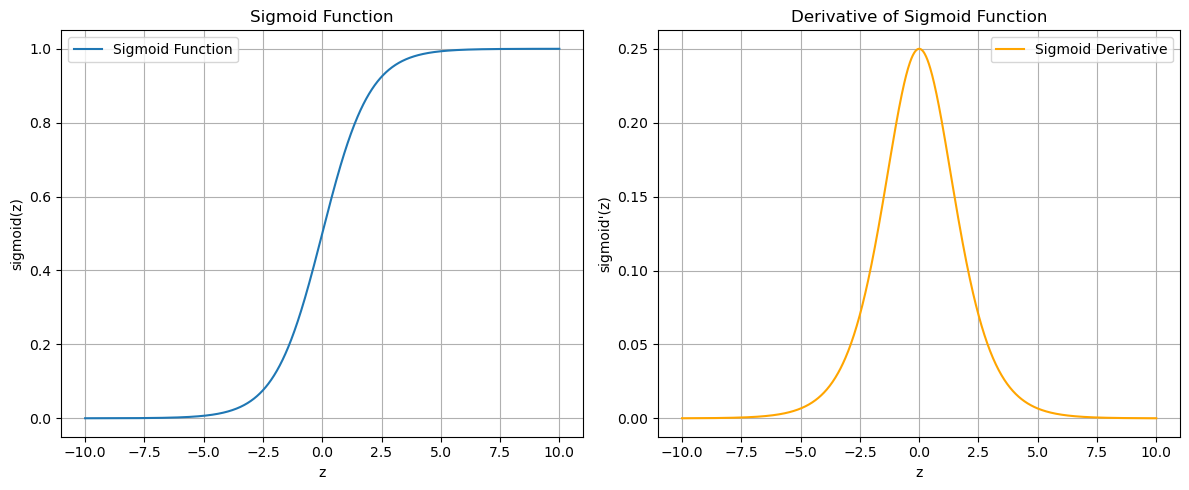

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

z = np.linspace(-10, 10, 1000)
sigmoid_values = sigmoid(z)
derivative_values = sigmoid_derivative(z)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(z, sigmoid_values, label='Sigmoid Function')
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')    
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(z, derivative_values, label='Sigmoid Derivative', color='orange')
plt.title('Derivative of Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid\'(z)')
plt.grid()
plt.legend()

plt.tight_layout()

## ReLU Function
The ReLU (Rectified Linear Unit) activation function is defined as:
```math
f(x) = \max(0, x)
```

$$f(x) = \begin{cases}
0 & \text{if } x \leq 0 \\
x & \text{if } x > 0
\end{cases}$$

Where:
- $x$ is the input to the function.

The ReLU function outputs the input directly if it is positive; otherwise, it outputs zero. This means that for any input value less than or equal to zero, the output will be zero, and for any input value greater than zero, the output will be equal to the input.

Leaky ReLU is a variant of the ReLU function that allows a small, non-zero gradient when the input is negative so that the gradient does not become zero. It is defined as:
```math
f(x) = \begin{cases}
\alpha x & \text{if } x < 0 \\
x & \text{if } x \geq 0
\end{cases}
```

Where:
- $\alpha$ is a small constant (e.g., 0.01) that determines the slope of the function for negative input values.

This solve the dying ReLU problem, where neurons can become inactive and stop learning if they output zero for all inputs.

#### Derivative of ReLU Function
The derivative of the ReLU function is given by:
$$f'(x) = \begin{cases}
0 & \text{if } x \leq 0 \\
1 & \text{if } x > 0
\end{cases}$$

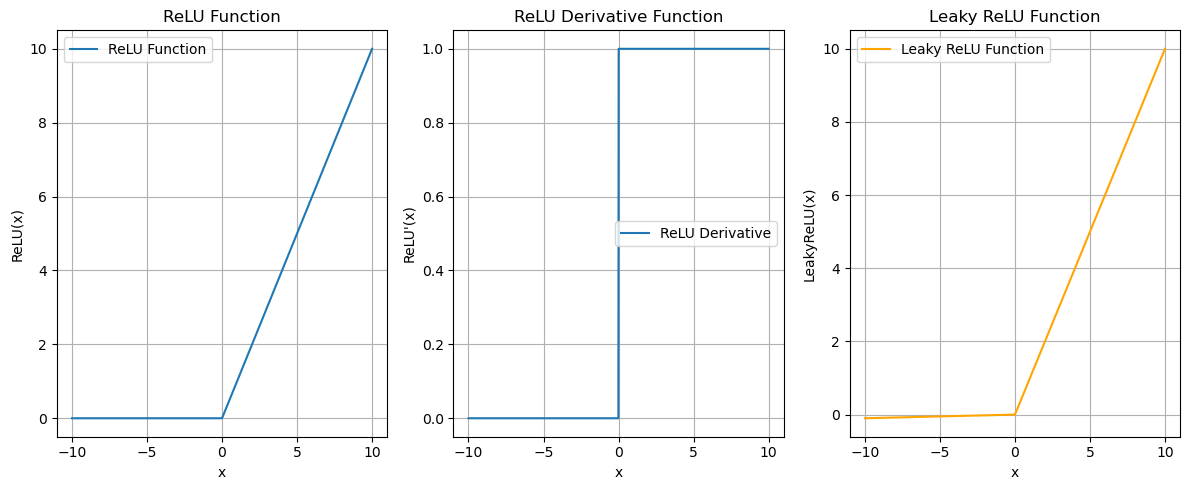

In [4]:
def ReLU(x):
    return np.maximum(0, x)

def ReLU_derivative(x):
    return np.where(x > 0, 1, 0)

def LeakyReLU(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

x = np.linspace(-10, 10, 1000)
relu_values = ReLU(x)
leaky_relu_values = LeakyReLU(x)
relu_derivative_values = ReLU_derivative(x)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(x, relu_values, label='ReLU Function')
plt.title('ReLU Function')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.grid()
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(x, relu_derivative_values, label='ReLU Derivative')
plt.title('ReLU Derivative Function')
plt.xlabel('x')
plt.ylabel("ReLU'(x)")
plt.grid()
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x, leaky_relu_values, label='Leaky ReLU Function', color='orange')
plt.title('Leaky ReLU Function')
plt.xlabel('x')
plt.ylabel('LeakyReLU(x)')
plt.grid()
plt.legend()

plt.tight_layout()

## Tanh Function
The Tanh (Hyperbolic Tangent) activation function is defined as:
```math
f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
```

Where:
- $x$ is the input to the function.

The Tanh function maps input values to a range between -1 and 1. It is similar to the sigmoid function but is centered around zero, which can help in centering the data and improving convergence during training.

#### Derivative of Tanh Function
The derivative of the Tanh function is given by:

The definition of the Tanh function:
$$f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Differentiate both sides with respect to $x$ using the quotient rule:
$$f'(x) = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2}$$
$$f'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2}$$
$$f'(x) = 1- \frac{(e^x-e^{-x})^2}{(e^x+e^{-x})^2}$$
$$f'(x) = 1 - \tanh^2(x)$$

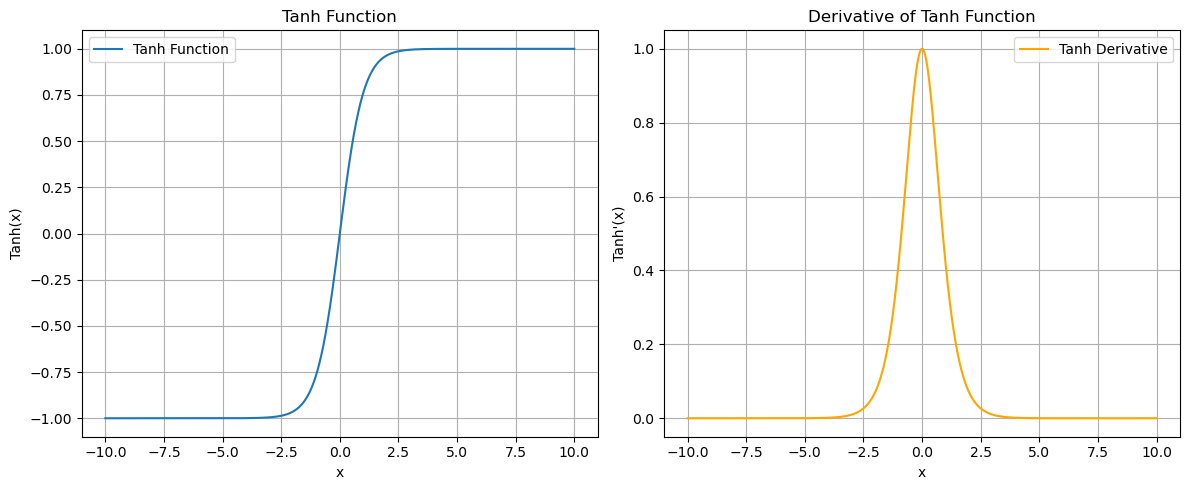

In [5]:
def Tanh(x):
    return np.tanh(x)   

def Tanh_derivative(x):
    t = Tanh(x)
    return 1 - t**2

x = np.linspace(-10, 10, 1000)
tanh_values = Tanh(x)
tanh_derivative_values = Tanh_derivative(x)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, tanh_values, label='Tanh Function')
plt.title('Tanh Function')
plt.xlabel('x')
plt.ylabel('Tanh(x)')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, tanh_derivative_values, label='Tanh Derivative', color='orange')
plt.title('Derivative of Tanh Function')
plt.xlabel('x')
plt.ylabel("Tanh'(x)")
plt.grid()
plt.legend()

plt.tight_layout()

## Softmax Function
The Softmax activation function is defined as:
```math
f(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}
```

Where:
- $z_i$ is the input to the function for the $i$-th class.
- $n$ is the total number of classes.

The Softmax function converts a vector of values into a probability distribution, often used in the output layer of multi-class classification problems. Each output value is between 0 and 1, and the sum of all output values is equal to 1, making it suitable for representing probabilities.

Example: Let $z = [1, 2, 3]$. The softmax output would be calculated as follows:    
1. Calculate the exponentials of each input:
   - $e^1 \approx 2.71828$
   - $e^2 \approx 7.38906$
   - $e^3 \approx 20.08554$
2. Sum the exponentials:
   - $2.71828 + 7.38906 + 20.08554 \approx 30.19288$
3. Calculate the softmax output for each input:
   - For $z_1$: $\frac{e^1}{30.19288} = \frac{2.71828}{30.19288} \approx 0.09003$
   - For $z_2$: $\frac{e^2}{30.19288} = \frac{7.38906}{30.19288} \approx 0.24473$
   - For $z_3$: $\frac{e^3}{30.19288} = \frac{20.08554}{30.19288} \approx 0.66524$

Thus, the softmax output for the input vector $z$ would be approximately $[0.09003, 0.24473, 0.66524]$, which represents the probabilities of each class.

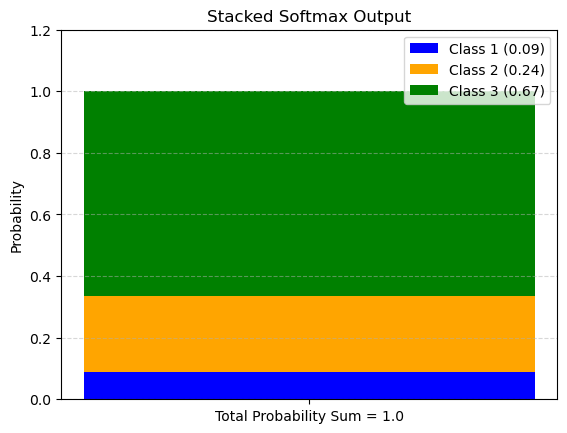

In [ ]:
def Softmax(x):
    # For numerical stability: subtract the max value before exponentiating
    # This prevents 'nan' results if x contains large numbers
    exp_x = np.exp(x - np.max(x)) 
    return exp_x / np.sum(exp_x)

x = np.array([1.0, 2.0, 3.0])
probs = Softmax(x)
v1, v2, v3 = probs

# Plotting the stacked bar
# The 'bottom' parameter tells matplotlib where the base of the bar starts
plt.bar(0, v1, color='blue', label=f'Class 1 ({v1:.2f})')
plt.bar(0, v2, bottom=v1, color='orange', label=f'Class 2 ({v2:.2f})')
plt.bar(0, v3, bottom=v1+v2, color='green', label=f'Class 3 ({v3:.2f})')

plt.title('Stacked Softmax Output')
plt.ylabel('Probability')
plt.xticks([0], ['Total Probability Sum = 1.0'])
plt.ylim(0, 1.2)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Binary Cross-Entropy Loss Function
The Binary Cross-Entropy Loss Function, also known as Log Loss, is a commonly used loss function for binary classification problems. It measures the performance of a classification model whose output is a probability value between 0 and 1. The formula for the binary cross-entropy loss function is given by:
```math
L = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]
```

Where:
- $L$ is the loss value.
- $N$ is the number of samples in the dataset.
- $y_i$ is the true label for the $i$-th sample (0 or 1).
- $p_i$ is the predicted probability for the $i$-th sample (output of the sigmoid function).

The binary cross-entropy loss function penalizes the model more when it makes incorrect predictions with high confidence. For example, if the true label is 1 and the predicted probability is close to 0, the loss will be high. Conversely, if the true label is 0 and the predicted probability is close to 1, the loss will also be high. The goal of training a binary classification model is to minimize this loss function, which can be achieved using optimization algorithms like gradient descent.

Example: Suppose we have a binary classification problem with the following true labels and predicted probabilities for 4 samples:
| Sample | True Label ($y_i$) | Predicted Probability ($p_i$) |
|--------|--------------------|-----------------------------|
| 1      | 1                  | 0.9                         |
| 2      | 0                  | 0.2                         |
| 3      | 1                  | 0.4                         |
| 4      | 0                  | 0.8                         |

To calculate the binary cross-entropy loss for these samples, we can use the formula:
1. For Sample 1: $- [1 \cdot \log(0.9) + (1 - 1) \cdot \log(1 - 0.9)] = -\log(0.9) \approx 0.10536$
2. For Sample 2: $- [0 \cdot \log(0.2) + (1 - 0) \cdot \log(1 - 0.2)] = -\log(0.8) \approx 0.22314$ 
3. For Sample 3: $- [1 \cdot \log(0.4) + (1 - 1) \cdot \log(1 - 0.4)] = -\log(0.4) \approx 0.91629$
4. For Sample 4: $- [0 \cdot \log(0.8) + (1 - 0) \cdot \log(1 - 0.8)] = -\log(0.2) \approx 1.60944$

To calculate the average loss across all samples, we can sum the individual losses and divide by the number of samples:
$$L = \frac{0.10536 + 0.22314 + 0.91629 + 1.60944}{4} \approx 0.71306$$

#### How Loss Function is Derived
The binary cross-entropy loss function is derived from the concept of maximum likelihood estimation (MLE) in statistics. In a binary classification problem, we want to maximize the likelihood of the observed data given the model's parameters. It means if a sample has a probability of 0.9 for the true class, we want to maximize that probability. Conversely, if a sample has a probability of 0.2 for the true class, we want to minimize that probability. Multiplying the probabilities for all samples together gives us the likelihood of the observed data.

$$P = \prod_{i=1}^{N} p_i$$

We choose the model whoose parameters maximize this likelihood. But the problem is, in real world, we have a lot of samples, and multiplying many probabilities together can lead to numerical instability (very small numbers). To avoid this, we take the logarithm of the likelihood, which turns the product into a sum:

$$\log(P) = \sum_{i=1}^{N} \log(p_i)$$

Since we want to maximize the likelihood, add a negative sign to convert it into a minimization problem(as $p_i$ is between 0 and 1, $\log(p_i)$ will be negative, so we need to negate it to make it positive):

$$L = -\sum_{i=1}^{N} \log(p_i)$$

In the case of binary classification, we need to account for both the true positive and true negative cases. Therefore, we can express the loss function as:
$$L = -\sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]$$

Finally, to get the average loss per sample, we divide by the number of samples $N$:
$$L = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]$$

#### Advantages & Disadvantages of Single Layer Perceptron

| Advantages | Disadvantages |
| :--- | :--- |
| Simple and easy to understand | Can only solve linearly separable problems |
| Fast training | Cannot solve XOR problem |
| Computationally efficient | Uses step function (not differentiable) |
| Works well for simple binary classification | Does not provide probability output |
| Easy mathematical formulation | Limited expressive power (no hidden layer) |